In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
import pickle
import shap
from lime.lime_tabular import LimeTabularExplainer

from pathlib import Path
root_dir = Path.cwd().parent
sys.path.append(str(root_dir))
from utils.helpers import set_global_settings, reverse_power_transform, create_shap_waterfall, get_recommended_values

In [2]:
RANDOM_STATE = int(os.getenv("RANDOM_STATE", 100))

# Apply global settings
set_global_settings()

In [3]:
target_variable = 'loan_status'
parent_data_dir = root_dir / "datasets"

train_df = pd.read_csv(parent_data_dir / "sampled_train_data.csv")
test_df = pd.read_csv(parent_data_dir / "test_set.csv")

X_train = train_df.drop(columns=[target_variable])
y_train = train_df[target_variable]

X_test = test_df.drop(columns=[target_variable])
y_test = test_df[target_variable]

In [4]:
parent_model_dir = root_dir / "models"

with open(parent_model_dir / "best_model.pkl", "rb") as f:
    model = pickle.load(f)

with open(parent_model_dir / "power_transformer.pkl", "rb") as f:
    transformer = pickle.load(f)

In [5]:
shap_explainer = shap.TreeExplainer(
    model, 
    X_train, 
    model_output='probability', 
    feature_perturbation="interventional",      # probability output requires this
    feature_names=X_train.columns
    )
shap_obj = shap_explainer(X_test)

100%|===================| 4383/4391 [01:12<00:00]        

In [6]:
num_variables = ['person_age', 'person_income', 'loan_amount', 'loan_interest_rate', 'credit_score']

X_test_rev = reverse_power_transform(X_test, num_variables, transformer)

X_test_rev.head()

,person_age,person_education,person_income,person_home_ownership,loan_amount,loan_intent,loan_interest_rate,credit_score,previous_loan_defaults
0,32.00,1,162857.25,2,6000.00,2,7.69,621.00,0
1,31.00,3,58395.00,2,5000.00,4,7.78,661.00,1
2,23.00,2,48769.00,3,6400.00,0,8.32,640.00,0
3,28.00,3,71418.00,2,5500.00,0,6.76,699.00,1
4,25.00,3,97110.00,1,10000.00,4,8.10,601.00,1


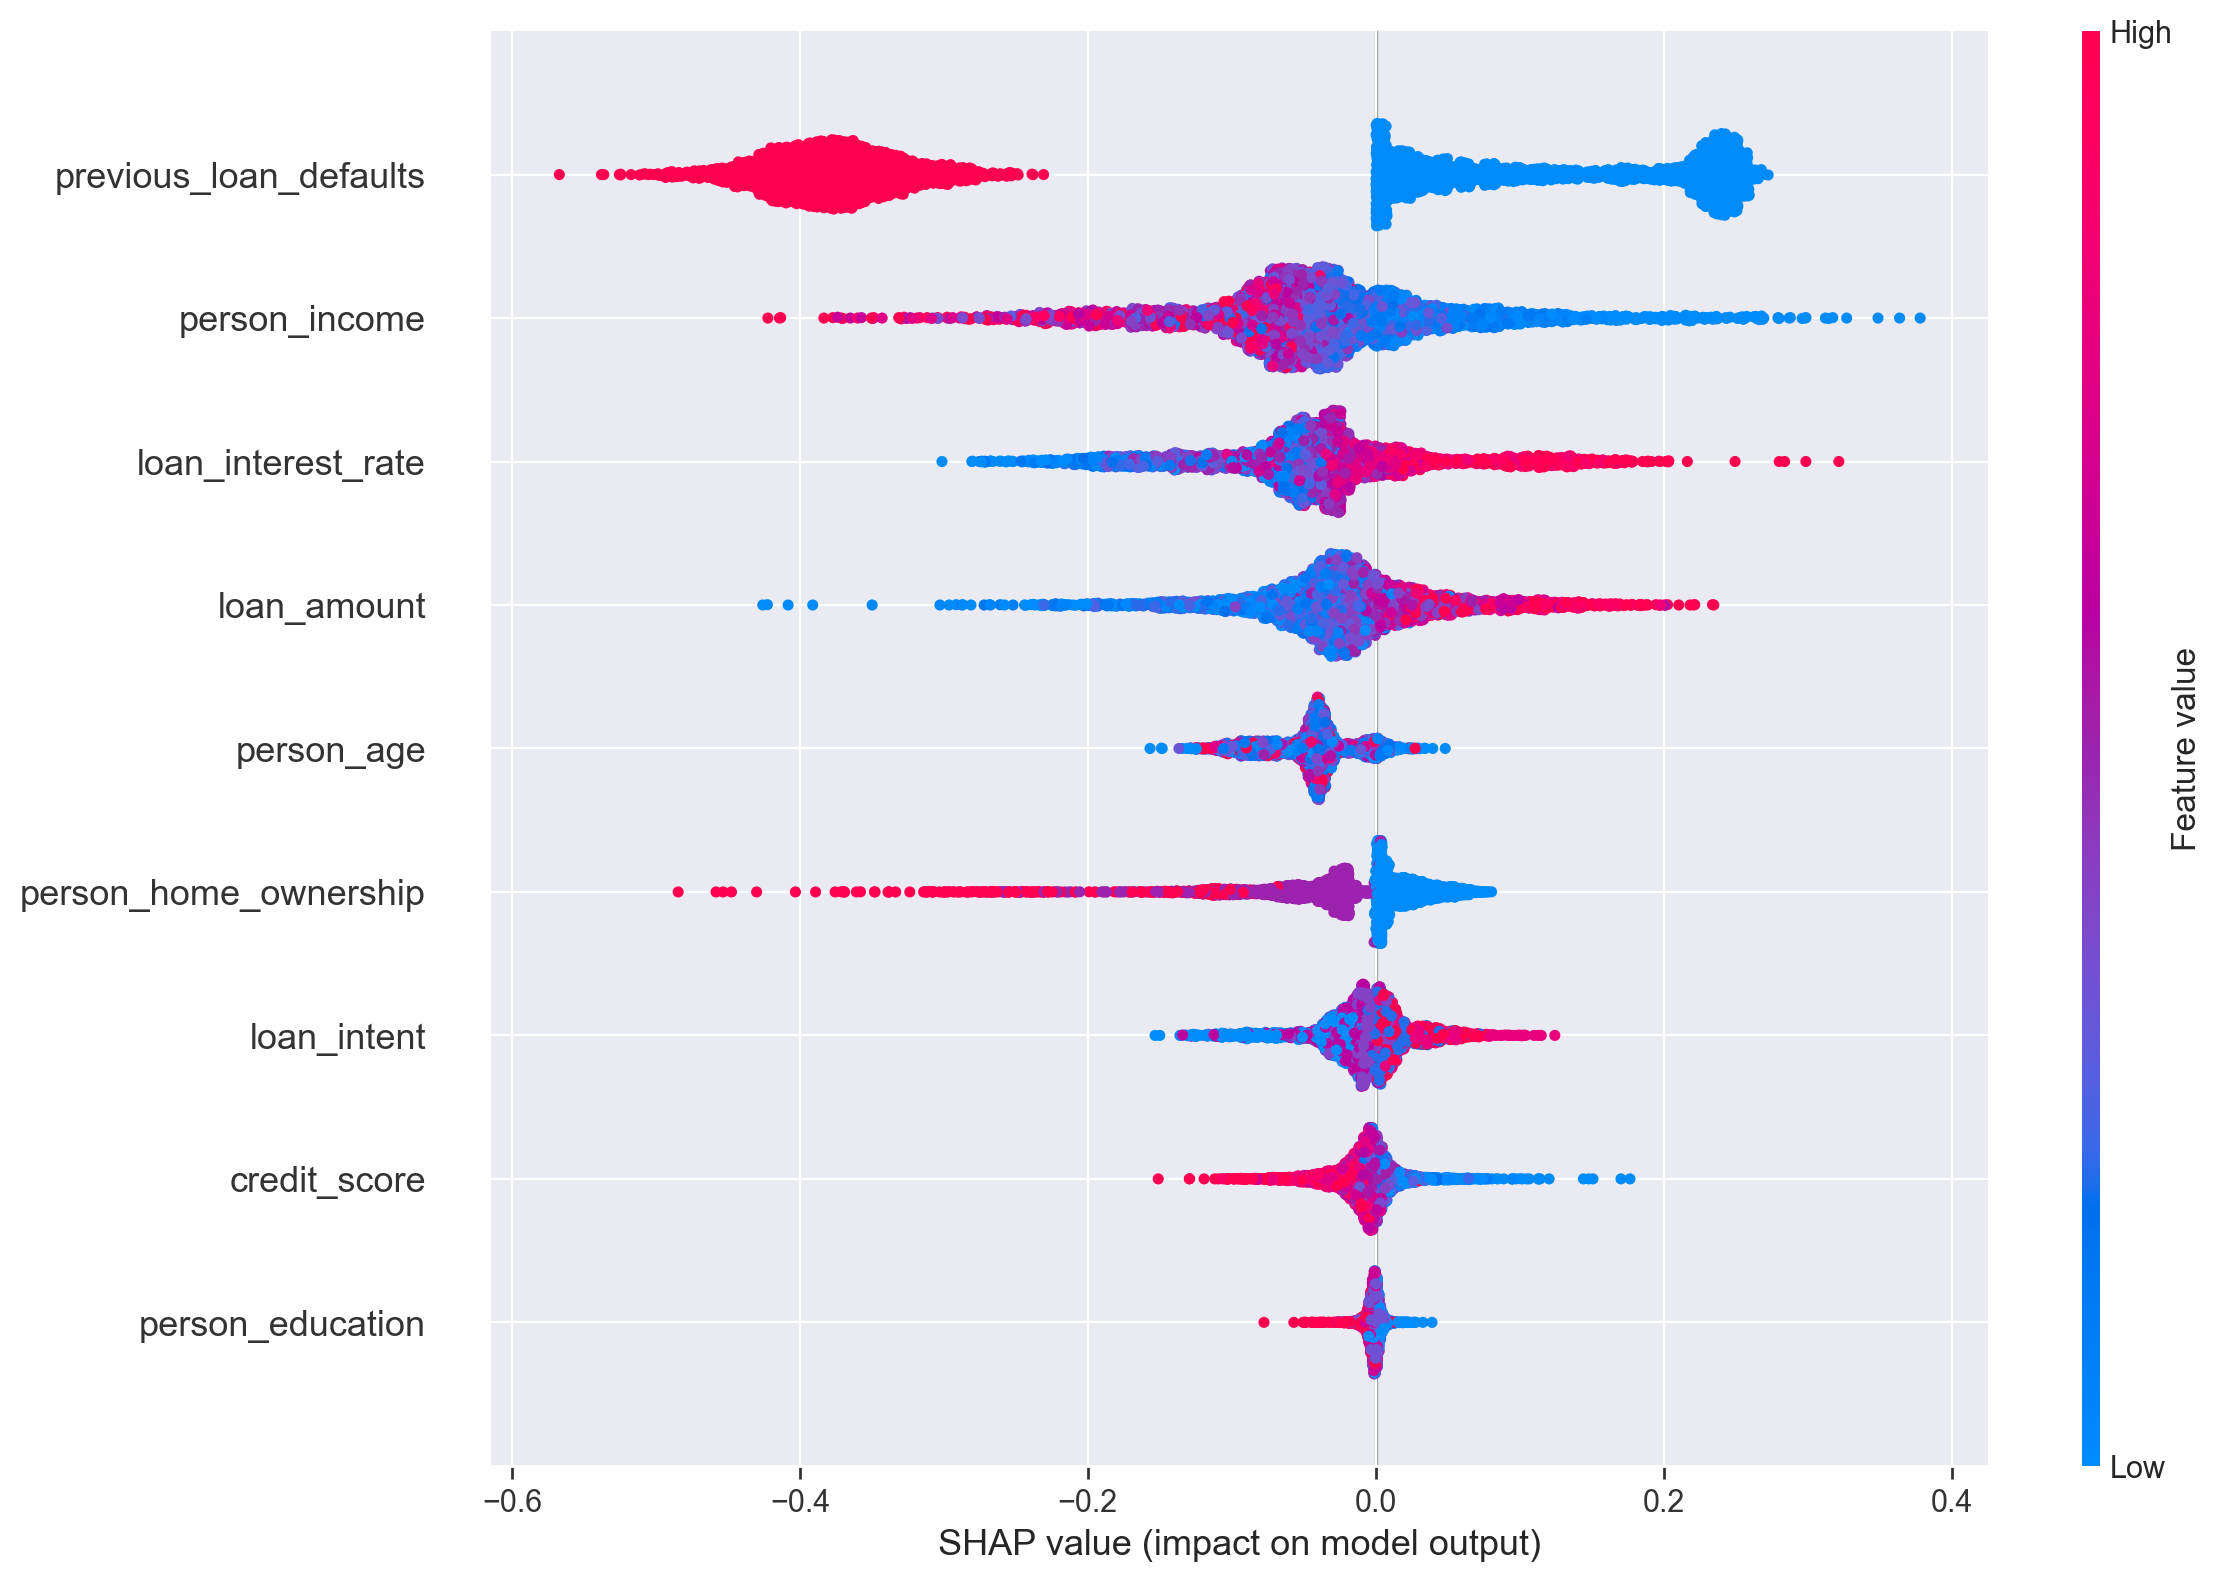

<Figure size 1280x960 with 0 Axes>

In [7]:
shap.summary_plot(shap_obj.values, X_test_rev, plot_size=(12,8))
plt.tight_layout()
plt.show()

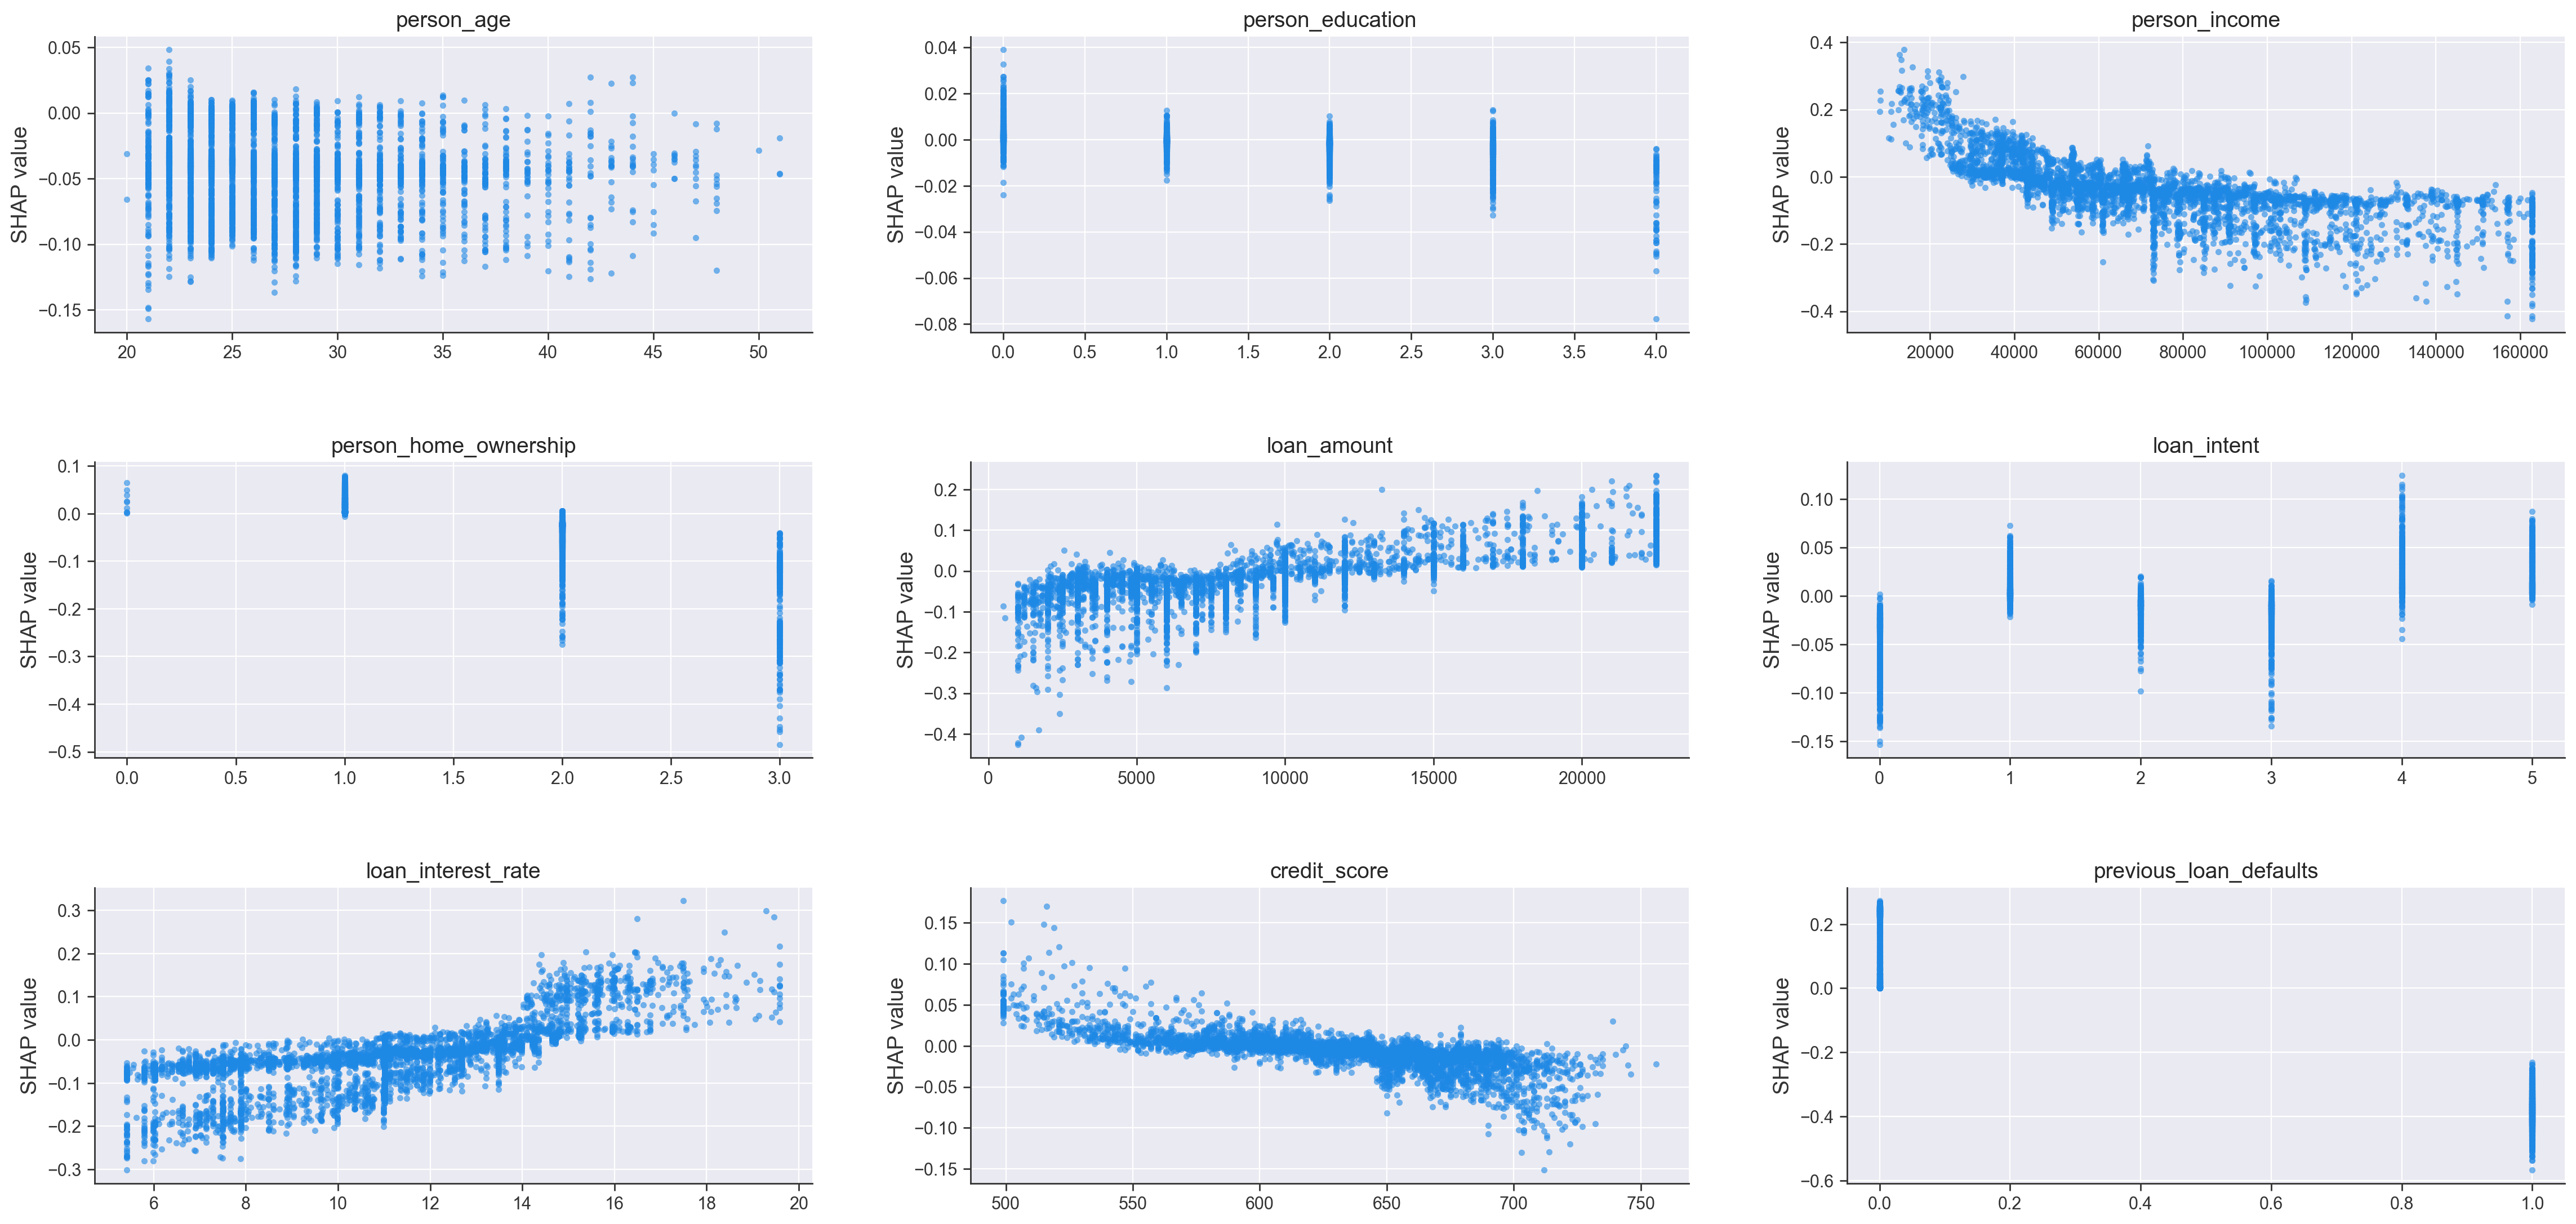

In [8]:
features = X_train.columns.to_list()

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(24,12))
axes = axes.flatten()

for ax, f in zip(axes, features):
    plt.sca(ax)
    shap.dependence_plot(
        f,
        shap_obj.values,
        X_test_rev,
        interaction_index=None,
        alpha=0.6,
        ax=ax,
        show=False
    )
    ax.set_title(f, fontsize=14)
    ax.set_ylabel("SHAP value", fontsize=14)
    ax.set_xlabel("")

plt.tight_layout(pad=5)
plt.show()

We will now explain the two most contrasting predictions. One with higher probability and one with lower probability.

In [9]:
# predicted probabilities
y_proba = model.predict_proba(X_test)[:, 1]

Explaining higher loan chance

In [10]:
# most positive prediction
pos_idx = np.argmax(y_proba)

X_test_rev.loc[pos_idx,:]

person_age                  33.00
person_education             0.00
person_income            31858.00
person_home_ownership        1.00
loan_amount              14559.00
loan_intent                  2.00
loan_interest_rate           9.23
credit_score               653.00
previous_loan_defaults       0.00
Name: 3729, dtype: float64

Positive index: 3729 
Probability: 0.9999167211361052


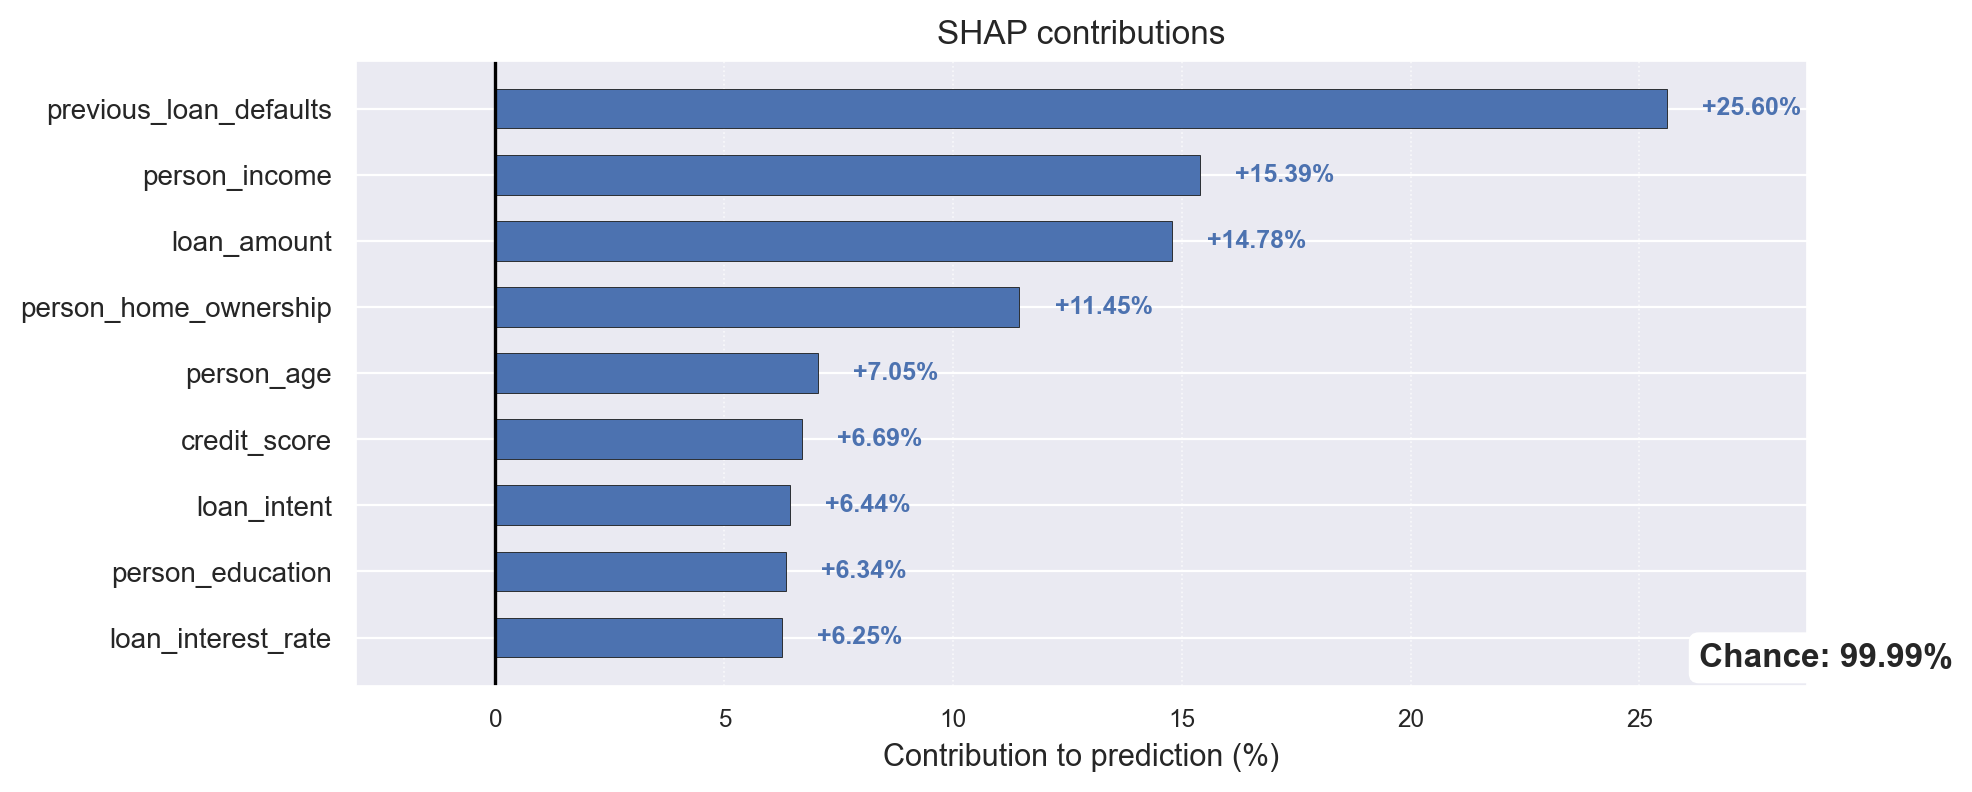

In [11]:
print("Positive index:", pos_idx, "\nProbability:", y_proba[pos_idx])

create_shap_waterfall(shap_obj, pos_idx)

Lower loan chance

In [12]:
# most negative prediction
neg_idx = np.argmin(y_proba)

X_test_rev.loc[neg_idx,:]

person_age                  22.00
person_education             1.00
person_income            67179.00
person_home_ownership        3.00
loan_amount               1275.00
loan_intent                  0.00
loan_interest_rate           6.91
credit_score               657.00
previous_loan_defaults       1.00
Name: 4167, dtype: float64

Negative index: 4167 
Probability: 3.1246440136652046e-06


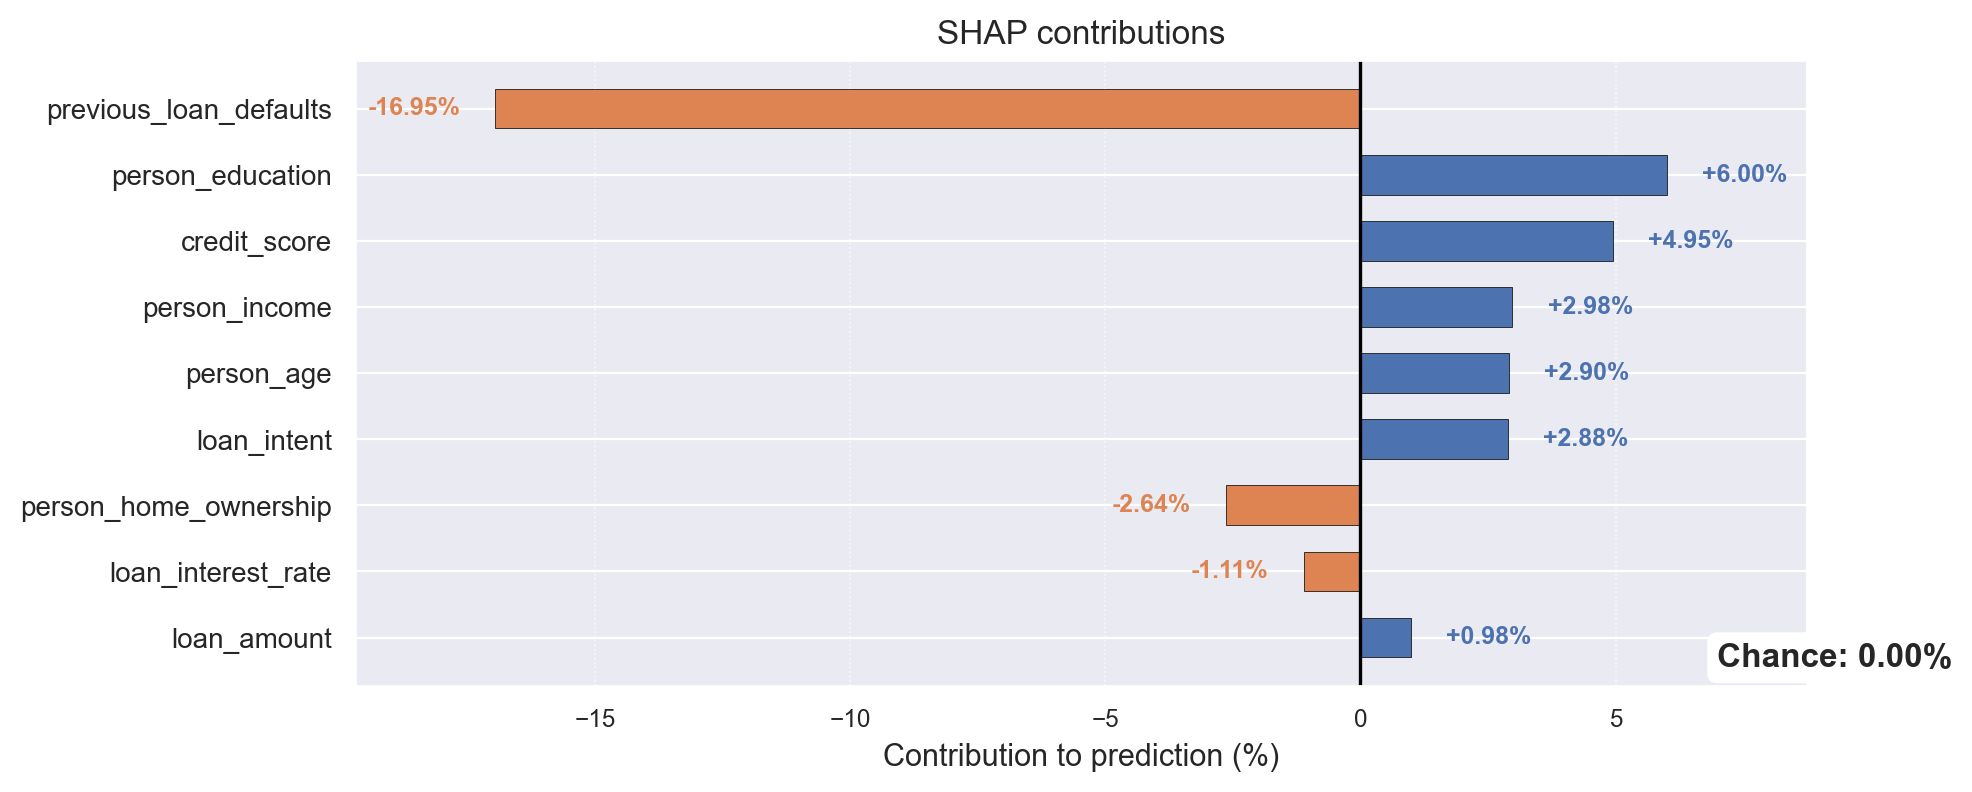

In [13]:
print("Negative index:", neg_idx, "\nProbability:", y_proba[neg_idx])

create_shap_waterfall(shap_obj, neg_idx)

Random instance. Run it as many times as you want.

person_age                  22.00
person_education             2.00
person_income            41502.00
person_home_ownership        2.00
loan_amount              12000.00
loan_intent                  0.00
loan_interest_rate          10.74
credit_score               697.00
previous_loan_defaults       0.00
Name: 2271, dtype: float64


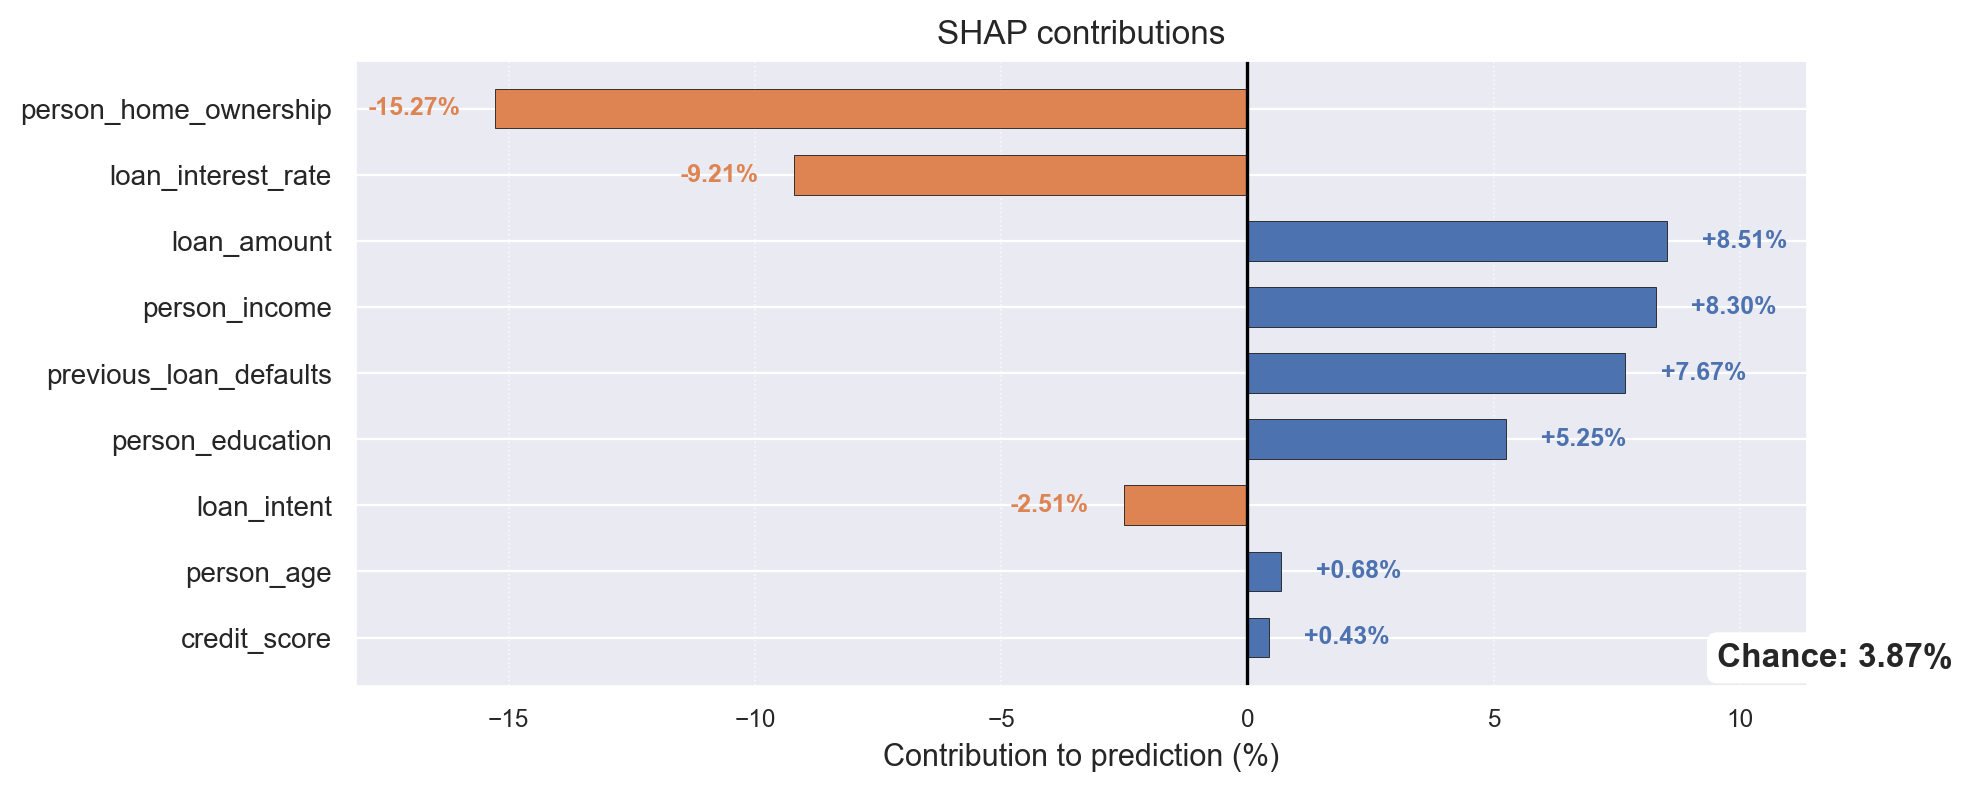

In [14]:
random_idx = X_test.sample(1).index[0]
print(X_test_rev.loc[random_idx,:])

create_shap_waterfall(shap_obj, random_idx)

LIME

In [15]:
cat_variables_idx = [1, 3, 5, 8]

lime_explainer = LimeTabularExplainer(
    training_data=X_train.values,
    training_labels=y_train,
    feature_names=X_train.columns,
    categorical_features=cat_variables_idx,
    kernel_width=np.sqrt(X_train.shape[1]) * 0.25,
    sample_around_instance=True,
    discretize_continuous=False,
    mode='classification',
    verbose=True,
    random_state=RANDOM_STATE
)

Intercept -0.165633179475562
Prediction_local [0.95459636]
Right: 0.9999167211361052


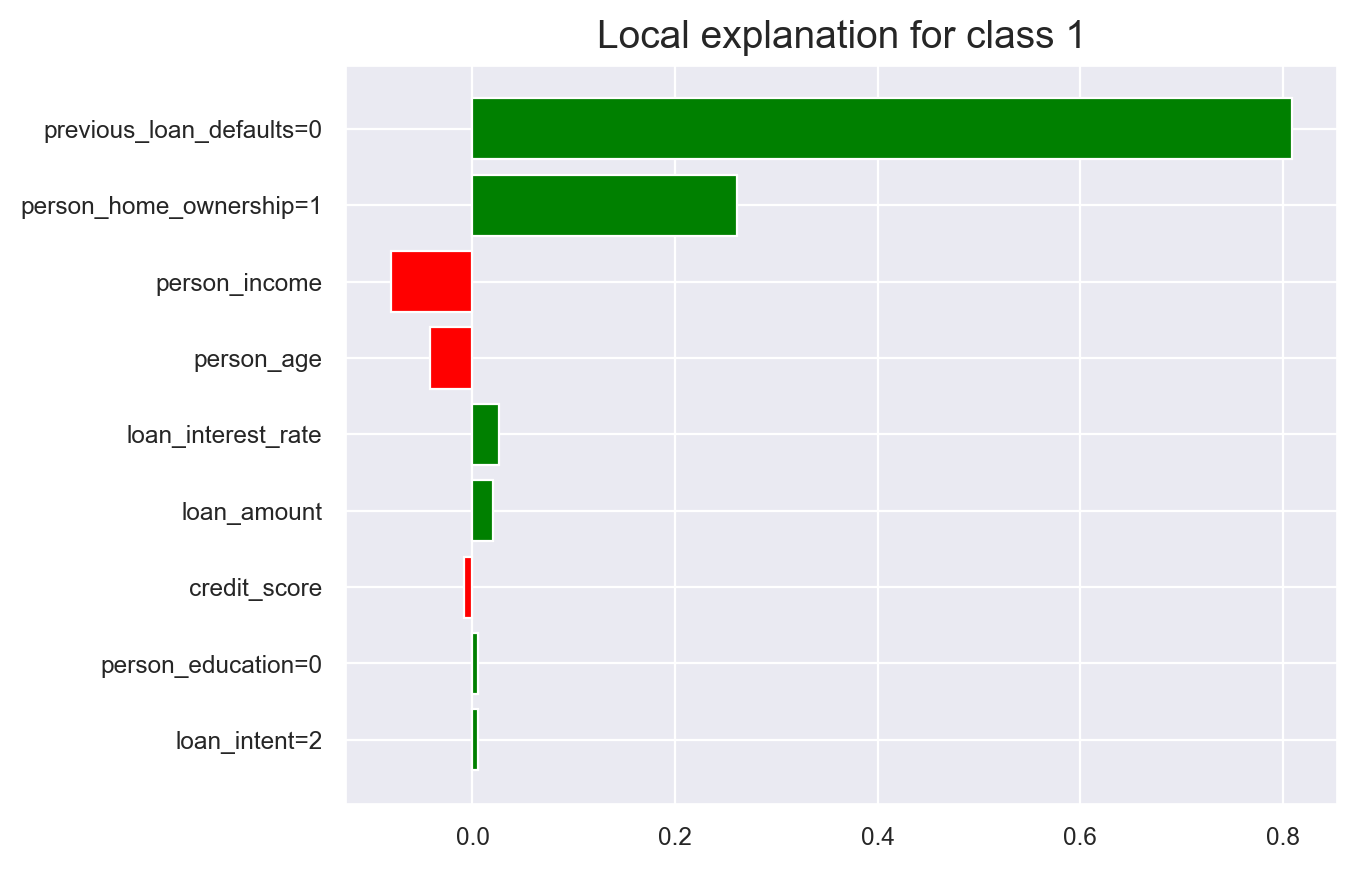

In [16]:
pos_exp = lime_explainer.explain_instance(
    data_row = X_test.iloc[pos_idx].values,
    predict_fn = model.predict_proba
)
_ = pos_exp.as_pyplot_figure()

`Prediction_local` is sum of all explanation values and `Intercept`. It is an approximation of model probability for that instance

`Right` is the actual model probability that the record is an instance of class `1`.

Intercept 0.5969234600184803
Prediction_local [-0.12899744]
Right: 3.1246440136652046e-06


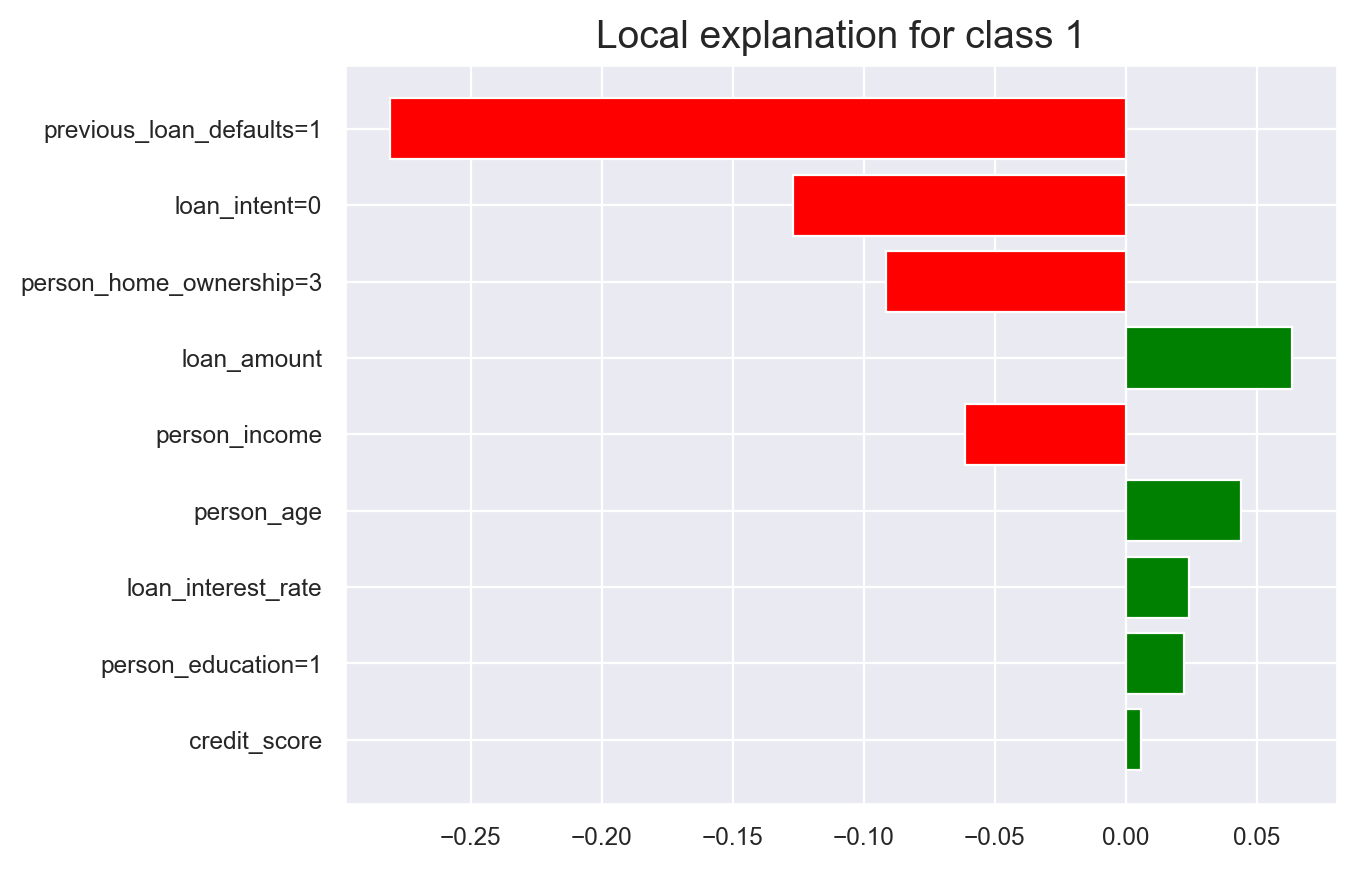

In [17]:
neg_exp = lime_explainer.explain_instance(
    data_row = X_test.iloc[neg_idx].values,
    predict_fn = model.predict_proba
)
_ = neg_exp.as_pyplot_figure()

Intercept 0.3053136952230573
Prediction_local [0.55859575]
Right: 0.038661530730792426


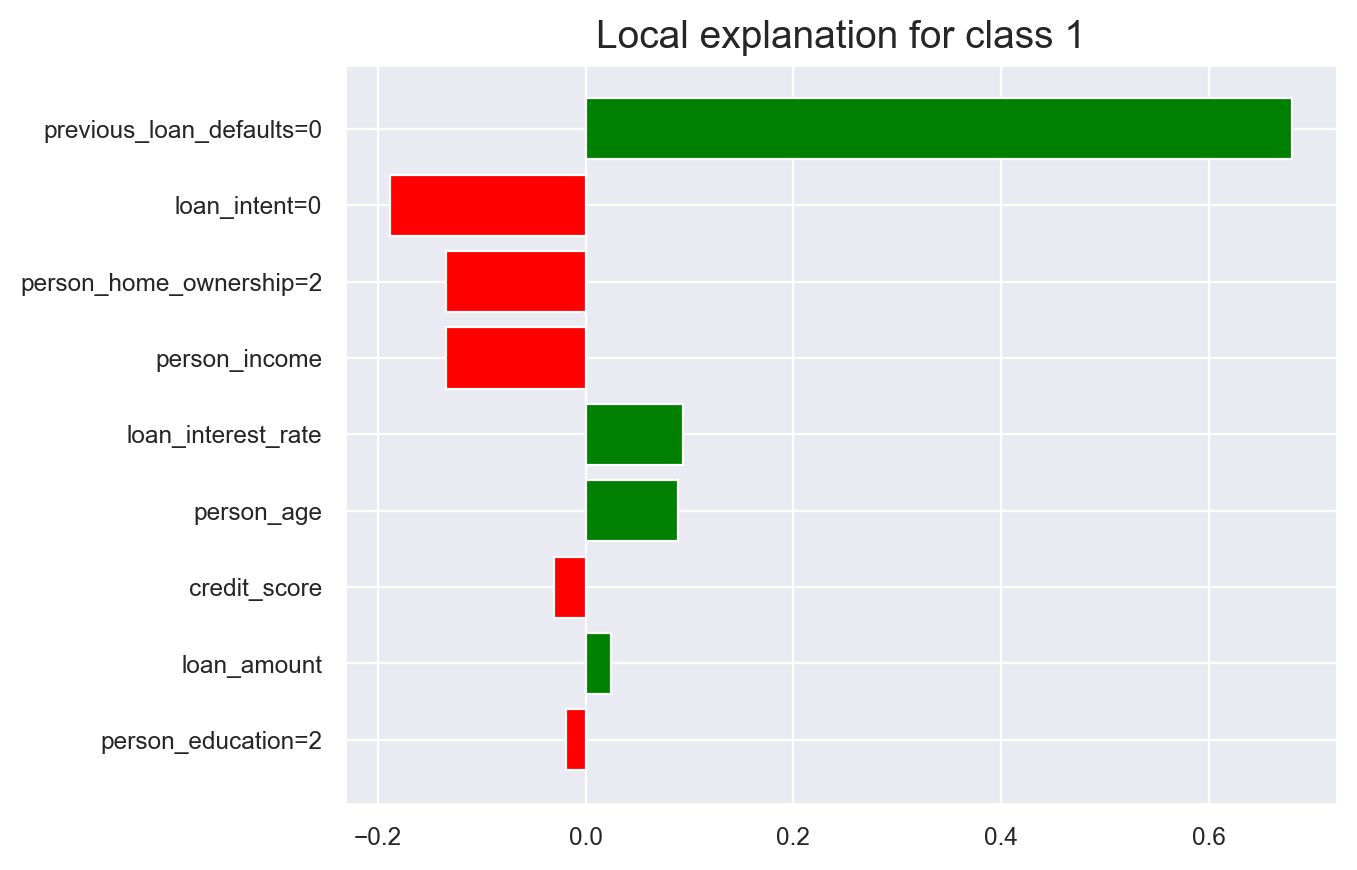

In [18]:
random_exp = lime_explainer.explain_instance(
    data_row = X_test.iloc[random_idx].values,
    predict_fn = model.predict_proba
)
_ = random_exp.as_pyplot_figure()

### SHAP vs LIME

#### Generating recommended interest rates if chances of approval less than 75%

In [21]:
random_row = X_test.sample(1).copy()
row_index = random_row.index[0]
old_pred = model.predict_proba(random_row)[0,1]

if old_pred >= 0.75:
    print("Chance is already quite high. Run the cell again")
else:
    curr_rate = X_test_rev.iloc[row_index, 6]
    print(f"Current interest rate: {curr_rate}\n")

    best_val = get_recommended_values(
        random_row.values.flatten(),
        model,
        lime_explainer,
        feature_idx=6,                     # interest rate is 7th column
        prob_threshold=old_pred + 0.20     # atleast 20% increase in chances
    )

    if best_val is not None:
        random_row.iloc[0, 6] = best_val
        random_row_rev = reverse_power_transform(random_row, num_variables, transformer)
        new_pred = model.predict_proba(random_row)[0,1]
        diff = max(new_pred - old_pred, 0) * 100

        best_rev = random_row_rev.iloc[0, 6]
        print(f"\nIncreasing interest rate to {best_rev} increased chances by {diff}%")
    else:
        print("\nYour chance will not improve much.")


Current interest rate: 7.58

Intercept 0.3315257233860748
Prediction_local [0.60813621]
Right: 0.2372144373230418

Increasing interest rate to 12.694758842512092 increased chances by 31.825871285539286%


In [22]:
# Save the shap explainer
shap_exp_save_path = root_dir / "models" / "shap_explainer.pkl"
with open(shap_exp_save_path, 'wb') as f:
    pickle.dump(shap_explainer, f)

In [23]:
# Save lime explainer config
lime_config = {
    "training_data": X_train.values,
    "feature_names": X_train.columns,
    "categorical_features": cat_variables_idx,
    "discretize_continuous": False,
    "kernel_width": np.sqrt(X_train.shape[1]) * 0.25,
    "sample_around_instance": True,
    "mode": "classification"
}

lime_cfg_save_path = root_dir / "models" / "lime_config.pkl"
with open(lime_cfg_save_path, 'wb') as f:
    pickle.dump(lime_config, f)